In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Country-data.csv" 
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path,
)
country_names = df['country']
data = df.drop(['country'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

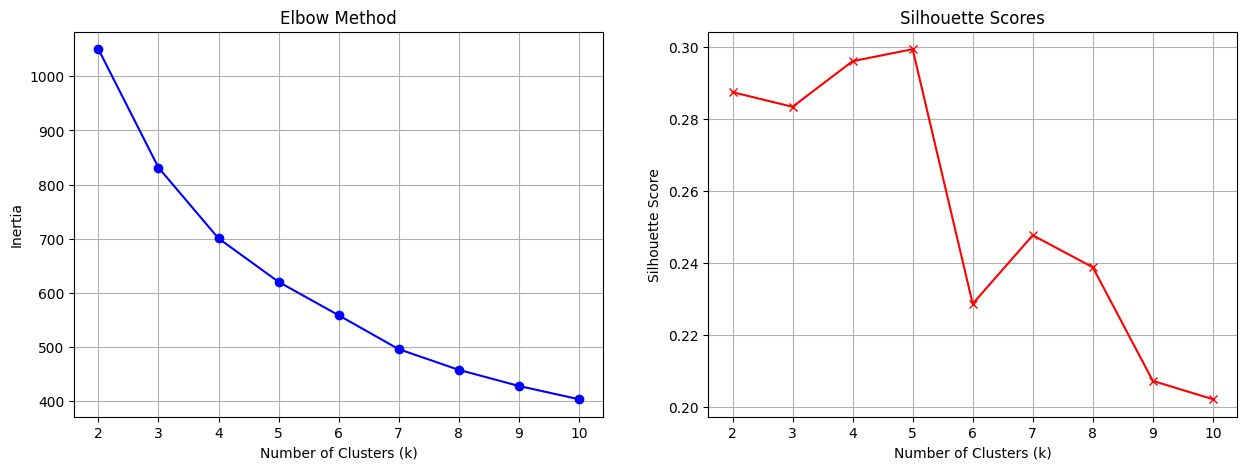

In [34]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting
plt.figure(figsize=(15, 5))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette, 'rx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.grid(True)

plt.show()

Based on the silhouette score and conrfirmed by the elbow method, the number of clusters recommended is five.

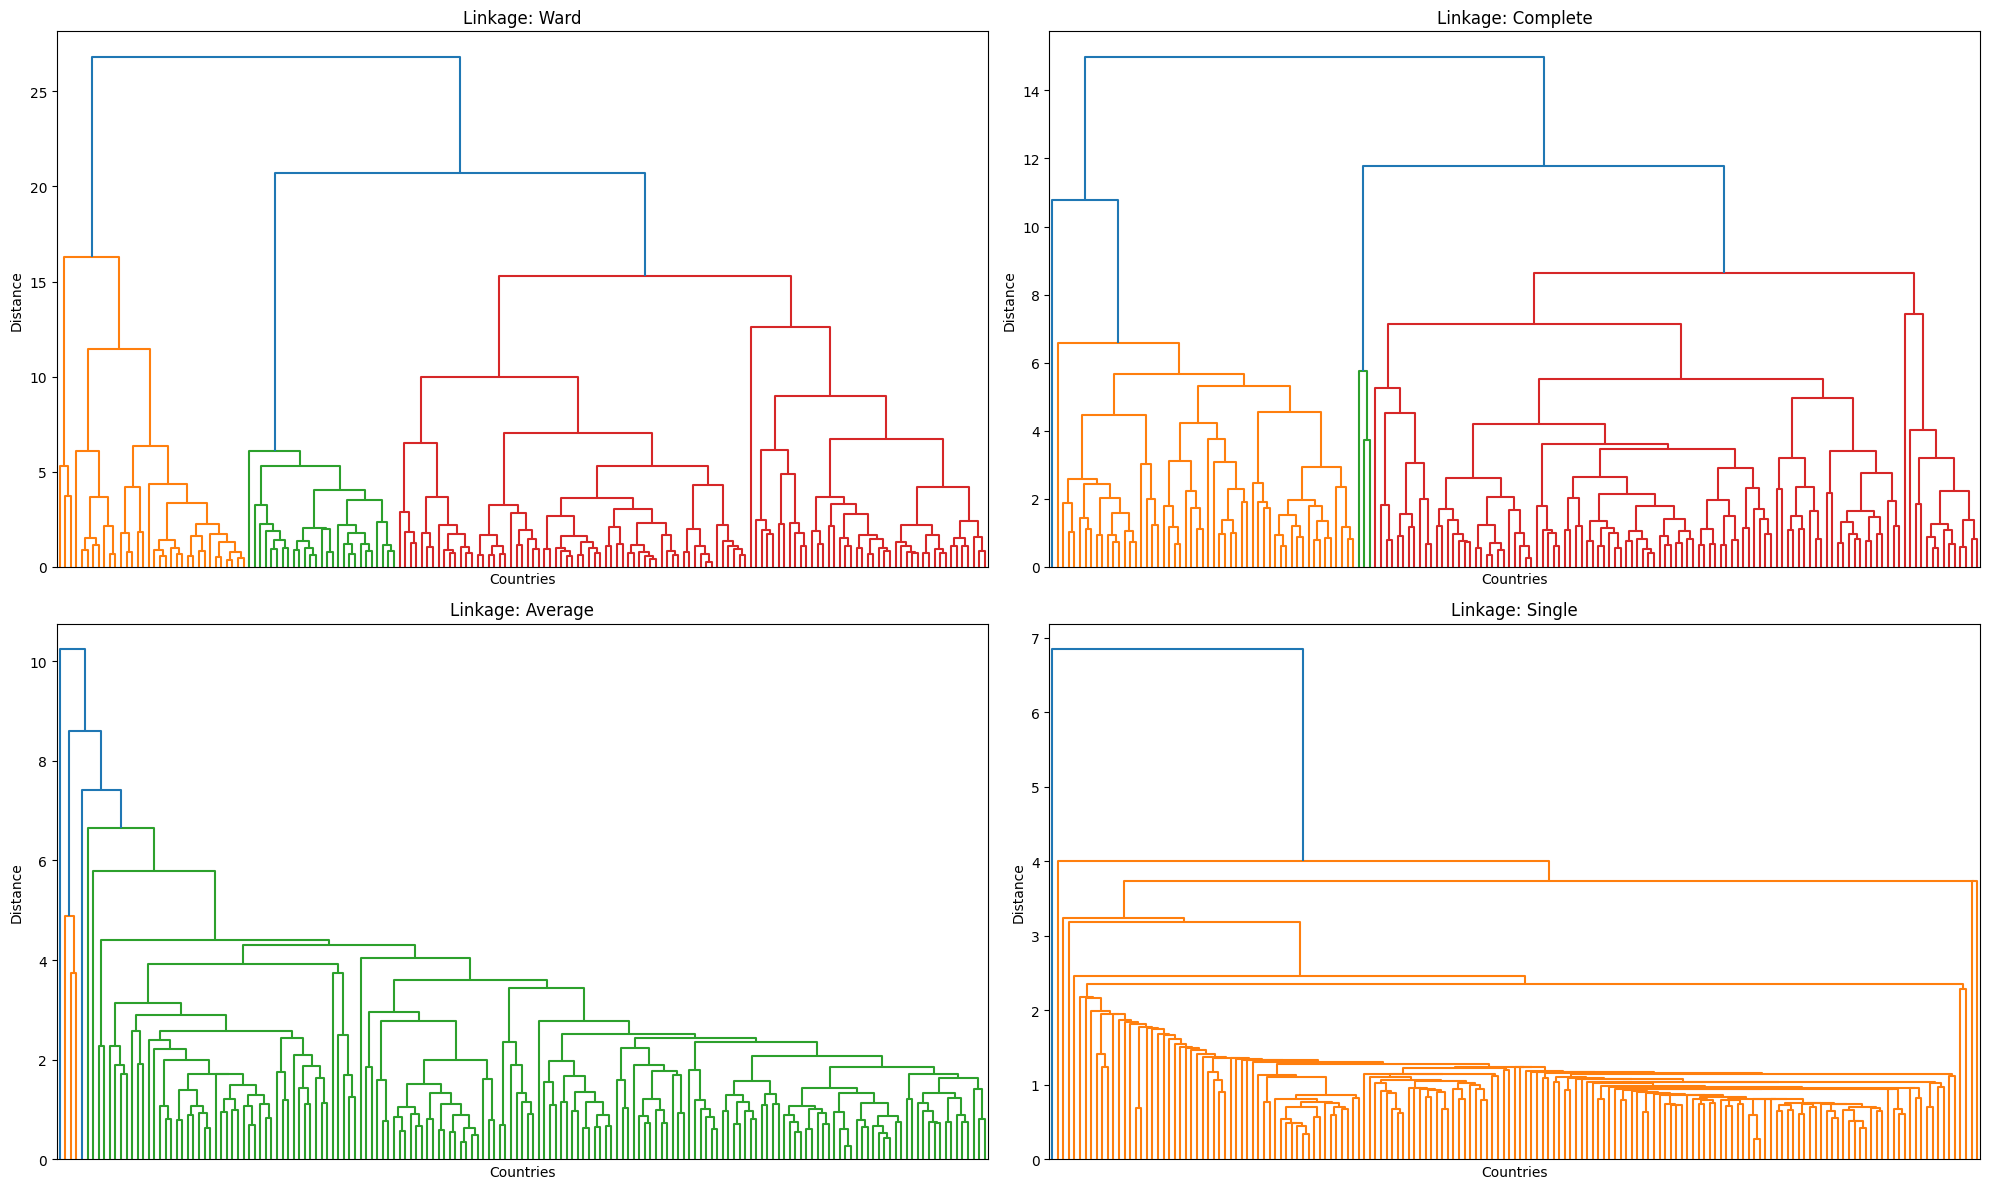

In [35]:
methods = ['ward', 'complete', 'average', 'single']
plt.figure(figsize=(20, 12))

for i, method in enumerate(methods):
    plt.subplot(2, 2, i + 1)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, no_labels=True)
    plt.title(f"Linkage: {method.capitalize()}")
    plt.xlabel("Countries")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()

Ward's linkage method is recommended because it produces a balanced hierarchy with clearly defined breaks. These clusters form distinct group of countries.

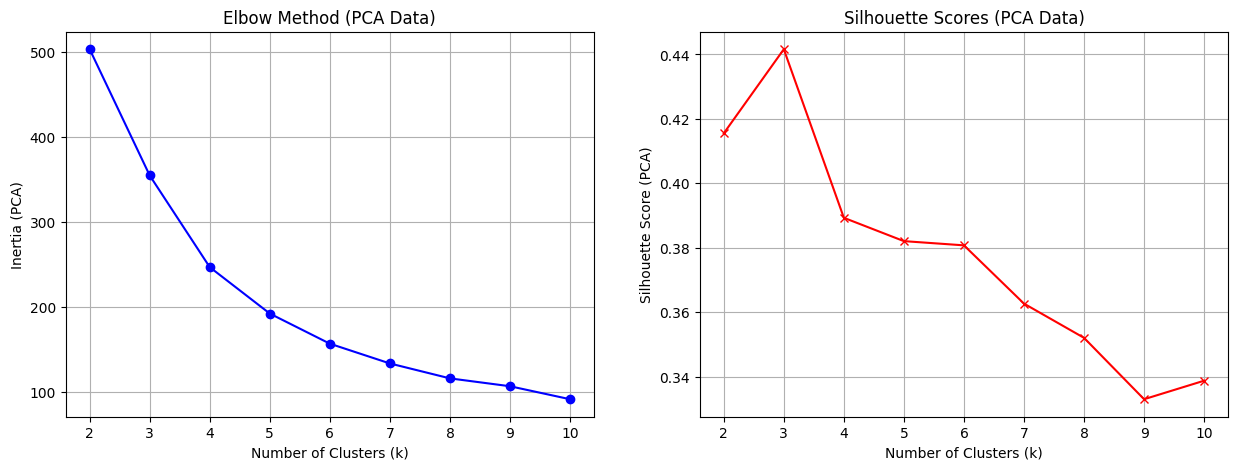

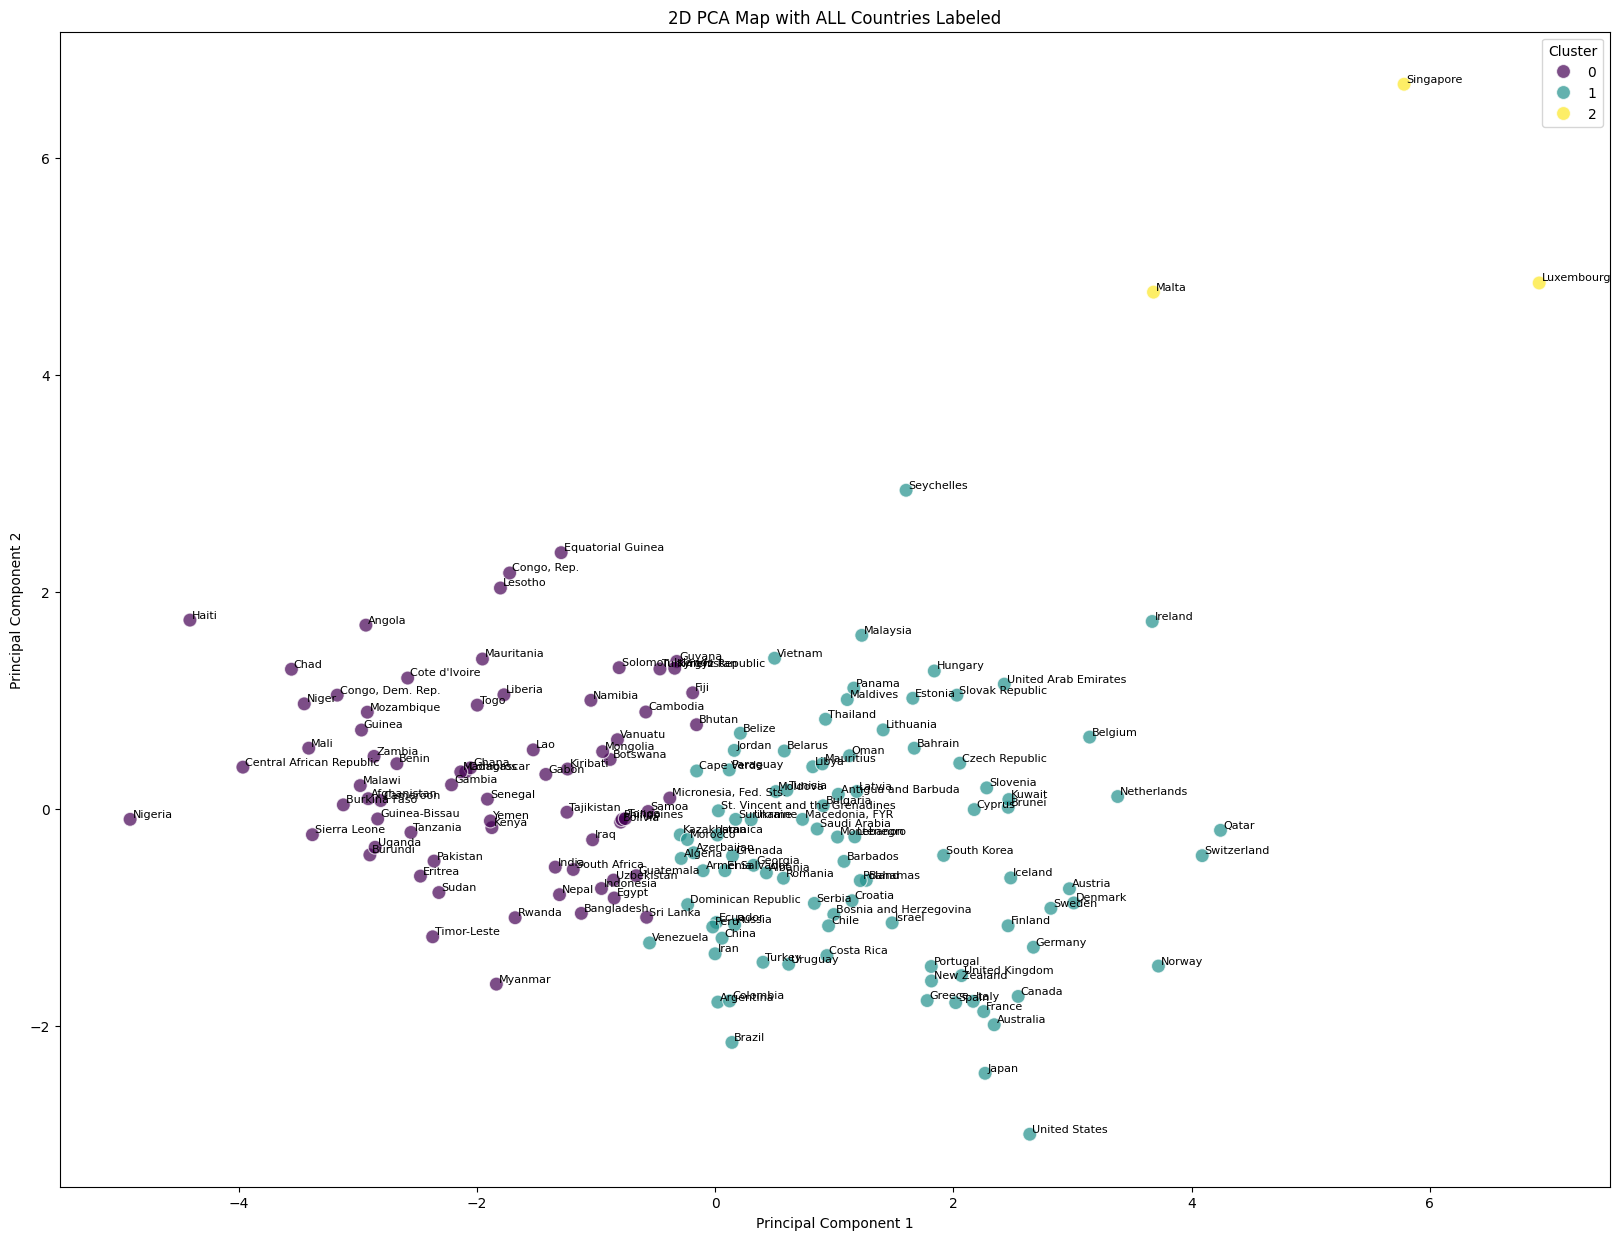

Average Values per Cluster:
         child_mort     exports    health     imports        income  \
Cluster                                                               
0         74.156338   30.611254  6.015915   44.071351   4363.281690   
1         11.974194   44.772043  7.426989   45.501075  25390.000000   
2          4.133333  176.000000  6.793333  156.666667  64033.333333   

         inflation  life_expec  total_fer          gdpp  
Cluster                                                  
0        11.094859   62.277465   4.329437   2019.211268  
1         5.423946   76.524731   1.943871  19881.182796  
2         2.468000   81.433333   1.380000  57566.666667  


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
inertia_pca = []
silhouette_pca = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia_pca.append(kmeans.inertia_)
    silhouette_pca.append(silhouette_score(X_pca, kmeans.labels_))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia_pca, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (PCA)')
plt.title('Elbow Method (PCA Data)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_pca, 'rx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score (PCA)')
plt.title('Silhouette Scores (PCA Data)')
plt.grid(True)
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=5, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels
df_pca['Country'] = country_names

plt.figure(figsize=(20, 15)) 
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100, alpha=0.7)

for i in range(df_pca.shape[0]):
    plt.text(
        df_pca.PC1[i] + 0.02, 
        df_pca.PC2[i] + 0.02, 
        df_pca.Country[i], 
        fontsize=8
    )

plt.title('2D PCA Map with ALL Countries Labeled')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

df['Cluster'] = cluster_labels
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
print("Average Values per Cluster:")
print(cluster_profile)

After performing 2D PCA, k-means clustering showed that three clusters are recommended. The first cluster consists of Singapore, Luxembourg, and Malta, which are city-states having these features: low child mortality, high exports and imports, high income, and GDPP. The second cluster consist of mostly developed countries with pretty good income and GDPP. The last cluster consist of developing countries from Africa and the Pacific with extremely rates of child mortality, very low income, high inflation, and very low GDPP.

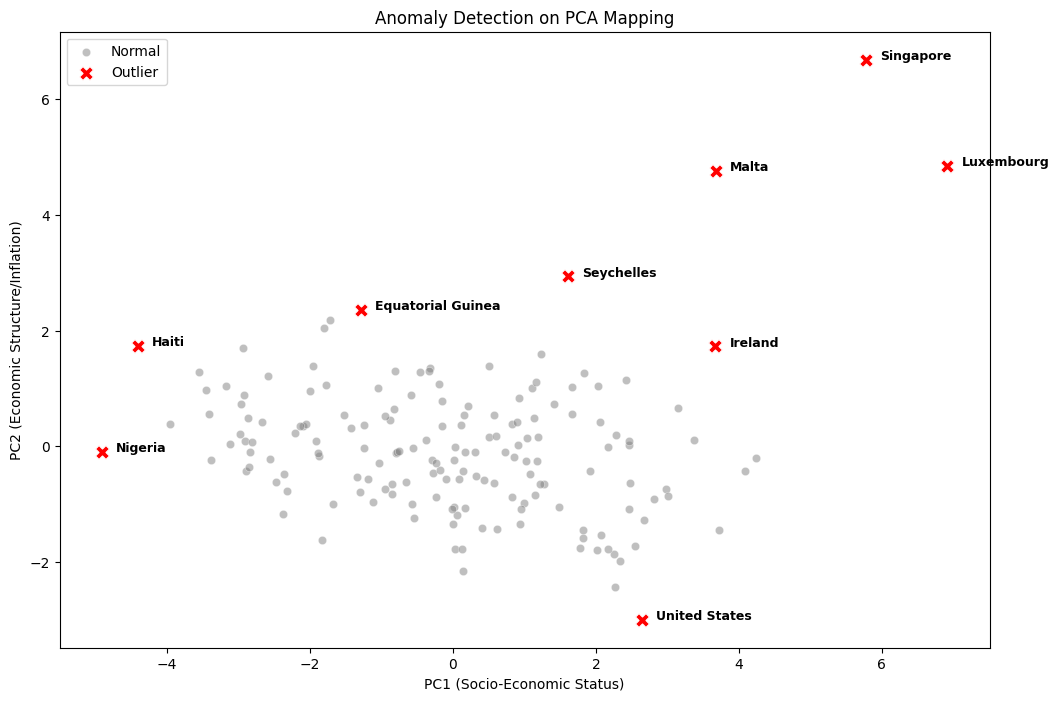

child_mort       38.270060
exports          41.108976
health            6.815689
imports          46.890215
income        17144.688623
inflation         7.781832
life_expec       70.555689
total_fer         2.947964
gdpp          12964.155689
dtype: float64

               country  child_mort  exports  health  imports  income  \
49   Equatorial Guinea       111.0     85.8    4.48     58.9   33700   
66               Haiti       208.0     15.3    6.91     64.7    1500   
73             Ireland         4.2    103.0    9.19     86.5   45700   
91          Luxembourg         2.8    175.0    7.77    142.0   91700   
98               Malta         6.8    153.0    8.65    154.0   28300   
113            Nigeria       130.0     25.3    5.07     17.4    5150   
131         Seychelles        14.4     93.8    3.40    108.0   20400   
133          Singapore         2.8    200.0    3.96    174.0   72100   
159      United States         7.3     12.4   17.90     15.8   49400   

     inflation  life

In [40]:
from sklearn.covariance import EllipticEnvelope
envelope = EllipticEnvelope(contamination=0.05, random_state=42)
outlier_pred = envelope.fit_predict(X_pca)
df_pca['Is_Outlier'] = outlier_pred # -1 for Outlier, 1 for Normal
outliers = df_pca[df_pca['Is_Outlier'] == -1]
normal_countries = df_pca[df_pca['Is_Outlier'] == 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', data=normal_countries, label='Normal', alpha=0.5, color='gray')
sns.scatterplot(x='PC1', y='PC2', data=outliers, label='Outlier', color='red', s=100, marker='X')

for i in outliers.index:
    plt.text(df_pca.PC1[i]+0.2, df_pca.PC2[i], df_pca.Country[i], fontsize=9, weight='bold', color='black')

plt.title('Anomaly Detection on PCA Mapping')
plt.xlabel('PC1 (Socio-Economic Status)')
plt.ylabel('PC2 (Economic Structure/Inflation)')
plt.show()

outlier_stats = df.loc[outliers.index]
print(data.mean())
print()
print(outlier_stats)

There are 9 identified outliers using the elliptic envelope method. Equitorial Guinea, Haiti, and Nigeria are outliers due to their high child mortality. Singapore, Luxembourg, and Malta have high imports and exports.Haiti has extremely low life expentancy, GDP per capita, and high tertility rate -> they are mostly ruled by gangs.

While Singapore, Luxembourg, and Malta belong to the rich city-state cluster, and Equatorial Guinea, Haiti, and Nigeria belong to the developing countries cluster; it is interesting to note what features makes some developed countries as outliers -> USA spends a lot on health. Ireland and the Seychelles seem to be in a recession. 